In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vihaankulkarni/antimicrobial-resistance-dataset/Kaggle_AMR_Dataset_v1.0.csv
/kaggle/input/datasets/vihaankulkarni/antimicrobial-resistance-dataset/processed/amr_dataset_variable_features.csv
/kaggle/input/datasets/vihaankulkarni/antimicrobial-resistance-dataset/processed/amr_dataset_final_prefixed.csv
/kaggle/input/datasets/vihaankulkarni/antimicrobial-resistance-dataset/processed/amr_summary_cleaned.csv
/kaggle/input/datasets/vihaankulkarni/antimicrobial-resistance-dataset/processed/amr_summary_dataset.csv


# ***Preparing, Downloading, and Exploratory dataset*** #

In [2]:
#Emporting the dataset to explore 
data = pd.read_csv('/kaggle/input/datasets/vihaankulkarni/antimicrobial-resistance-dataset/Kaggle_AMR_Dataset_v1.0.csv')
#Explore the columns of dataset:
data.columns
#print the data
print(data)

    Isolate_ID  Genome_Length_BP  GC_Content_Percent  gene_APH(3'')-Ib  \
0   AP035757.1           4784478               50.86                 0   
1   AP039418.1           5098687               50.58                 0   
2   AP040249.1           4940609               50.74                 0   
3   AP042483.1           5300047               50.74                 1   
4   AP042532.1           5451560               50.52                 0   
5   AP042561.1           5494199               50.54                 0   
6   AP042564.1           4971397               50.89                 0   
7   AP042570.1           5026011               50.75                 0   
8   AP042591.1           5473218               50.56                 0   
9   AP042594.1           5283251               50.60                 0   
10  AP042598.1           5299229               50.67                 1   
11  AP042616.1           5300431               50.67                 1   
12  AP042623.1           5299253      

In [3]:
#explore columns of the data
data.columns

Index(['Isolate_ID', 'Genome_Length_BP', 'GC_Content_Percent',
       'gene_APH(3'')-Ib', 'gene_APH(3')-Ia', 'gene_APH(6)-Id', 'gene_CMY-59',
       'gene_CRP', 'gene_CTX-M-14', 'gene_CTX-M-15',
       ...
       'biosample', 'bioproject', 'taxonomy', 'collection_year',
       'collection_month', 'collection_season', 'host_standardized',
       'isolation_source_standardized', 'total_amr_genes',
       'total_resistance_classes'],
      dtype='object', length=112)

In this cell, we try to create many heatmap to visualize the datasets of antimicrobial resistance genes 
first one will be figure out the appearance of two genes on the same bacteria isolate, indicate that selction of one antibiotic can affect on the other genes 

In [4]:
# 1- Creating heatmap showing the co-occurrence between two genes in same bacteria 
#import essential python data visaulization library
import matplotlib.pyplot as plt
import seaborn as sns

#2- Isolate gene columns 
gene_col = [
     "gene_APH(3'')-Ib",
    "gene_APH(3')-Ia", 
    "gene_APH(6)-Id",
    "gene_CMY-59",
       "gene_CRP",
    "gene_CTX-M-14",
    "gene_CTX-M-15"
]

#3- calculate the correlation matrix between genes, Pearson/Spearman correlation 
gene_corr = data[gene_col].corr()


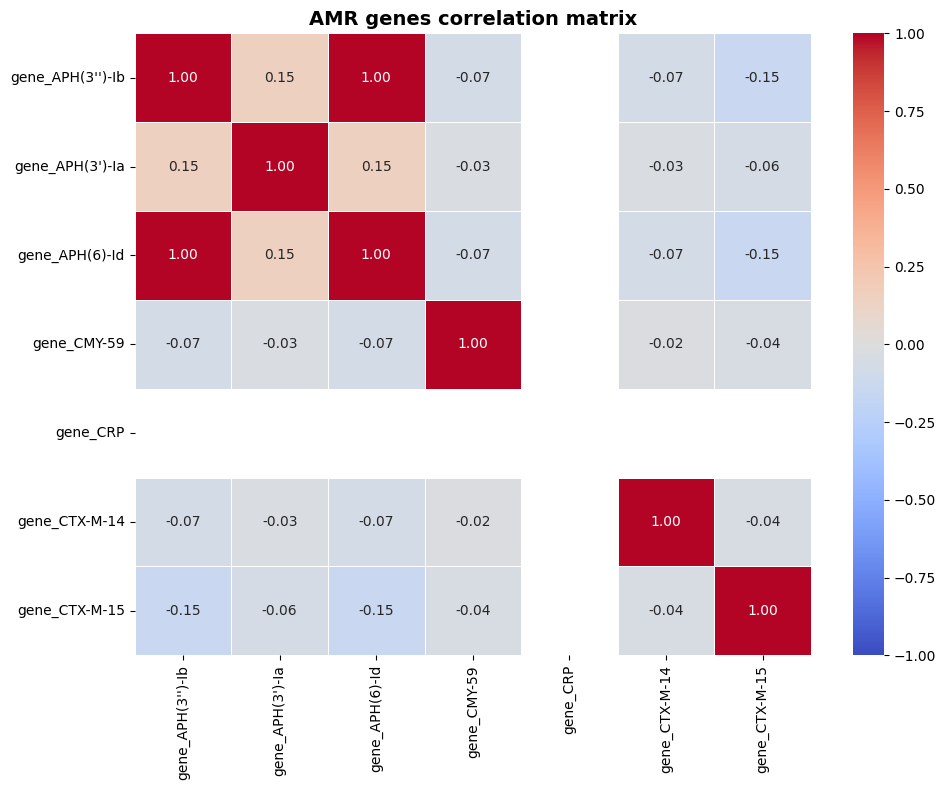

In [5]:
#3- Create Heatmap 
plt.figure(figsize=(10, 8))
sns.heatmap(
    gene_corr, 
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("AMR genes correlation matrix", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

The next cell shows the an epidomiology focus based on the *host_standarized* column. 

In [6]:
#Aggregation the data by grouping by the host_standarized column and figure out the mean
heatmap_data = data.groupby("host_standardized")[gene_col].mean()

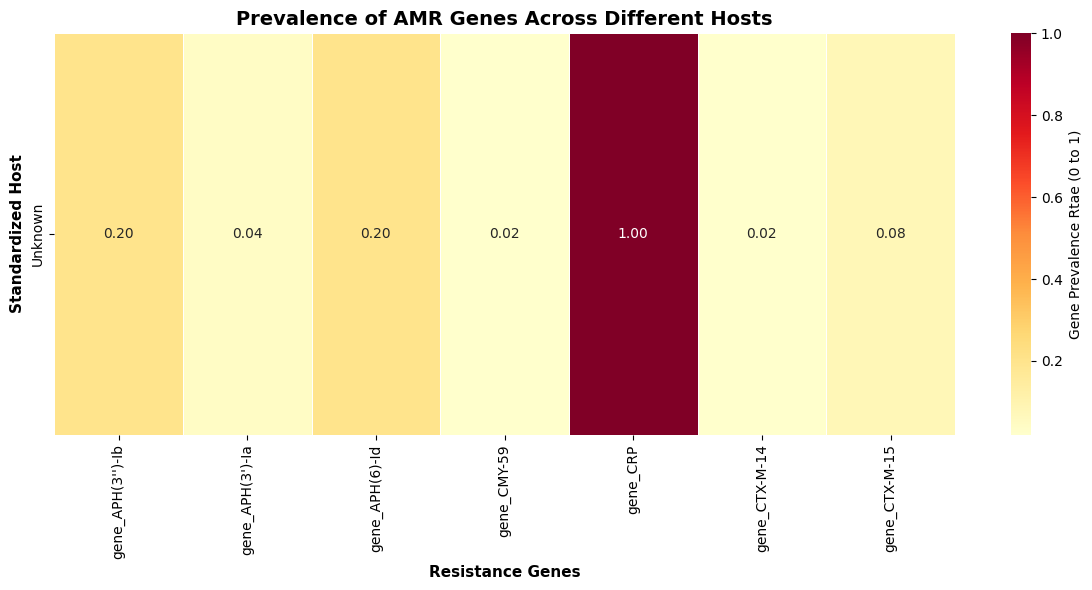

In [7]:
#plot with seaborn 
plt.figure(figsize=(12,6))
sns.heatmap(
    heatmap_data, 
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Gene Prevalence Rtae (0 to 1)"}
)

plt.title(
    "Prevalence of AMR Genes Across Different Hosts", fontsize=14, weight="bold")
plt.xlabel("Resistance Genes", fontsize=11, weight="bold")
plt.ylabel("Standardized Host", fontsize=11, weight="bold")
plt.tight_layout()
plt.show()

In [8]:
data['host_standardized']

0     Unknown
1     Unknown
2     Unknown
3     Unknown
4     Unknown
5     Unknown
6     Unknown
7     Unknown
8     Unknown
9     Unknown
10    Unknown
11    Unknown
12    Unknown
13    Unknown
14    Unknown
15    Unknown
16    Unknown
17    Unknown
18    Unknown
19    Unknown
20    Unknown
21    Unknown
22    Unknown
23    Unknown
24    Unknown
25    Unknown
26    Unknown
27    Unknown
28    Unknown
29    Unknown
30    Unknown
31    Unknown
32    Unknown
33    Unknown
34    Unknown
35    Unknown
36    Unknown
37    Unknown
38    Unknown
39    Unknown
40    Unknown
41    Unknown
42    Unknown
43    Unknown
44    Unknown
45    Unknown
46    Unknown
47    Unknown
48    Unknown
49    Unknown
Name: host_standardized, dtype: object

**Interpretation**# 
> Both heatmaps have no meaning and can`t explain the correlation between two or more genes, so the next step is to establish another heatmap based on taxonomy of bacteria isolates 

In [9]:
#Based on the columns of taxonomy
#filtering out the column (for trying) so that the heatmap won`t be cowded
top_tax = data["taxonomy"].value_counts().nlargest(10).index
top_tax

Index(['Bacteria; Pseudomonadati; Pseudomonadota; Gammaproteobacteria; Enterobacterales; Enterobacteriaceae; Escherichia'], dtype='object', name='taxonomy')

In [10]:
top_tax_filtered = data[data["taxonomy"].isin(top_tax)]
top_tax_filtered

,Isolate_ID,Genome_Length_BP,GC_Content_Percent,gene_APH(3'')-Ib,gene_APH(3')-Ia,gene_APH(6)-Id,gene_CMY-59,gene_CRP,gene_CTX-M-14,gene_CTX-M-15,...,biosample,bioproject,taxonomy,collection_year,collection_month,collection_season,host_standardized,isolation_source_standardized,total_amr_genes,total_resistance_classes
0,AP035757.1,4784478,50.86,0,0,0,0,1,0,0,...,SAMD00770530,PRJDB18000,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,45,23
1,AP039418.1,5098687,50.58,0,0,0,1,1,0,0,...,SAMD00874696,PRJDB19974,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,47,23
2,AP040249.1,4940609,50.74,0,0,0,0,1,1,0,...,SAMD00548845,PRJDB13852,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,51,25
3,AP042483.1,5300047,50.74,1,1,1,0,1,0,0,...,SAMD00899021,PRJDB20538,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,51,24
4,AP042532.1,5451560,50.52,0,0,0,0,1,0,0,...,SAMD00899031,PRJDB20538,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,46,23
5,AP042561.1,5494199,50.54,0,0,0,0,1,0,0,...,SAMD00899037,PRJDB20538,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,46,23
6,AP042564.1,4971397,50.89,0,0,0,0,1,0,0,...,SAMD00899038,PRJDB20538,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,46,23
7,AP042570.1,5026011,50.75,0,0,0,0,1,0,0,...,SAMD00899039,PRJDB20538,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,46,23
8,AP042591.1,5473218,50.56,0,0,0,0,1,0,0,...,SAMD00899043,PRJDB20538,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,46,23
9,AP042594.1,5283251,50.60,0,0,0,0,1,0,0,...,SAMD00899044,PRJDB20538,Bacteria; Pseudomonadati; Pseudomonadota; Gamm...,NaN,NaN,Unknown,Unknown,Unknown,45,23


In [11]:
#illustrate the heatmap 
heatmap_data = top_tax_filtered.groupby("taxonomy")[gene_col].mean()
heatmap_data

,gene_APH(3'')-Ib,gene_APH(3')-Ia,gene_APH(6)-Id,gene_CMY-59,gene_CRP,gene_CTX-M-14,gene_CTX-M-15
taxonomy,,,,,,,
Bacteria; Pseudomonadati; Pseudomonadota; Gammaproteobacteria; Enterobacterales; Enterobacteriaceae; Escherichia,0.204082,0.040816,0.204082,0.020408,1.0,0.020408,0.081633


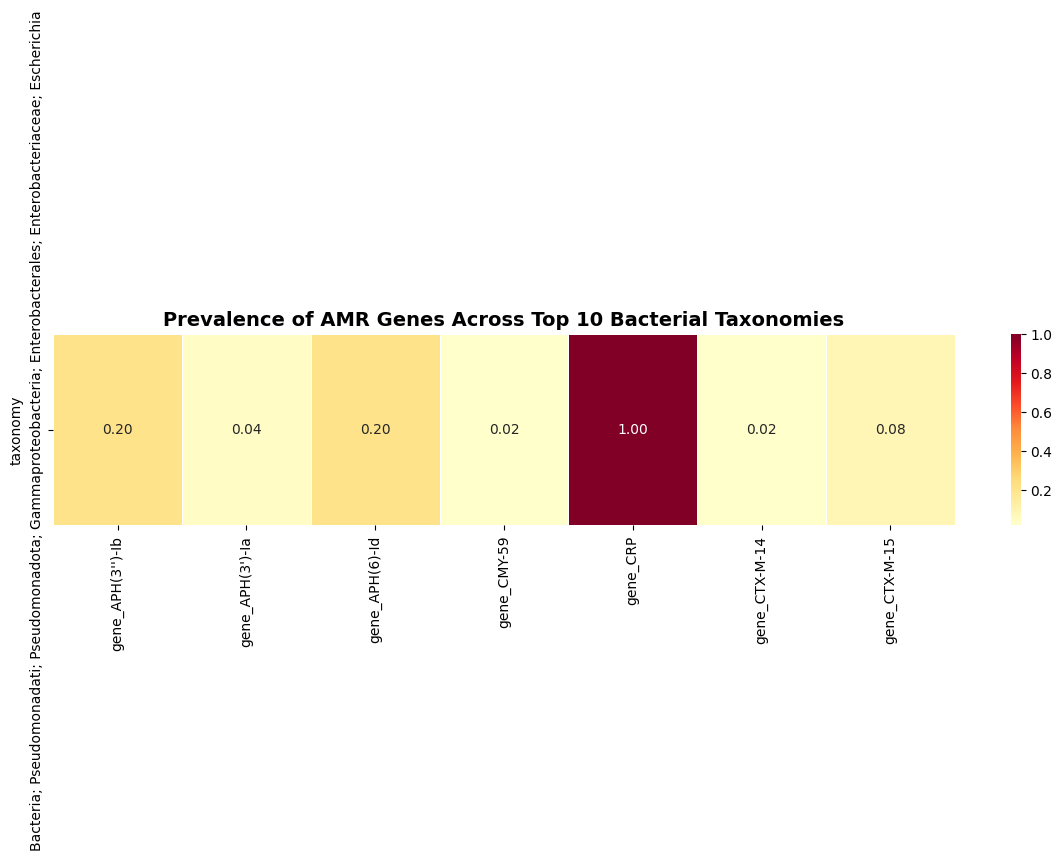

In [12]:
#illustrate by plotting
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("Prevalence of AMR Genes Across Top 10 Bacterial Taxonomies", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

>
# Building Classification/Prediction Model
>
>
 1- Building classification model by XGBoost
>
>
 2- Building Prediction model by LightGBM
 

# Error Fixing and Interpretation

This Section is for copy_paste the error messages and how they have been fixed

 1- **Target Leakage & Correlation of single gene**
 As a single gene showed a correlation of 0.1 with a taxonomy category, we tried reduced the extreme **Target Leakage** that cuased by the correlatiion, solved this error by removing the single leakage gene from predictor matrix before train_test splits. 

 2- **Small-Data Fragmentaion Crash**
 (`The minimum number of groups for any class cannot be less than 2`)
 The train-test splits cuase an error becuase of using 'stratify' parametrs on small lab sampling size (49 total rows) that have missing data (rare bacteria strains or unknown strains) of 1 sample. solved this errro by dropping stratification arguments, filtering and grouping the unknown strains as 'Other-Taxa'.

 3- **Label Indexing Error**
 (`ValueError: Expected: [0 1 2 3], got [22 23 24 25]`)
 XGBoost classification halted training, the unique class intger started from 22 not from 0, this error solved by Label-encoder.fit_transform() 

 4- **Encoder Type Crash**
 (`ValueError: object of type 'float' has no len()`)
 Label-encoder crashed when parsing the taxonomy column throwing length error as missing data in pandas stored as float-point decimals. this error solved by 'fillna('Other-Taxa').astype(str)' to normalize data primitives across all 49 rows before text vectorization.
 
 
 
 





In [13]:
# Fixing the 2 errors poped from the model, the first error appeared that "The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2."
# We are trying to fix it by python

# 1- Count the occurrences of each bacteria starin
counts = data['taxonomy'].value_counts()

# 2- Strains fewer than 5 times appearenace
unique_strains = counts[counts < 5].index

# 3. Replace the names of strains with general name
data["taxonomy"] = data["taxonomy"].replace(unique_strains, "Other_Taxa")

# test 
print(unique_strains)

# the second error "object of type 'float' has no len()", appeared as the features taxonom has missing data
data["taxonomy"] = data["taxonomy"].fillna("Other_Taxa").astype(str)

print(data["taxonomy"])

Index([], dtype='object', name='taxonomy')
0     Bacteria; Pseudomonadati; Pseudomonadota; Gamm...
1     Bacteria; Pseudomonadati; Pseudomonadota; Gamm...
2     Bacteria; Pseudomonadati; Pseudomonadota; Gamm...
3     Bacteria; Pseudomonadati; Pseudomonadota; Gamm...
4     Bacteria; Pseudomonadati; Pseudomonadota; Gamm...
5     Bacteria; Pseudomonadati; Pseudomonadota; Gamm...
6     Bacteria; Pseudomonadati; Pseudomonadota; Gamm...
7     Bacteria; Pseudomonadati; Pseudomonadota; Gamm...
8     Bacteria; Pseudomonadati; Pseudomonadota; Gamm...
9     Bacteria; Pseudomonadati; Pseudomonadota; Gamm...
10    Bacteria; Pseudomonadati; Pseudomonadota; Gamm...
11    Bacteria; Pseudomonadati; Pseudomonadota; Gamm...
12    Bacteria; Pseudomonadati; Pseudomonadota; Gamm...
13    Bacteria; Pseudomonadati; Pseudomonadota; Gamm...
14    Bacteria; Pseudomonadati; Pseudomonadota; Gamm...
15    Bacteria; Pseudomonadati; Pseudomonadota; Gamm...
16    Bacteria; Pseudomonadati; Pseudomonadota; Gamm...
17   

In [14]:
# Preprocessing so that preventing overfitting and target leakage
# ------------------------------------------------------------------------
# importing the libraries
import lightgbm as lgb 
from sklearn.metrics import (classification_report, mean_absolute_error, r2_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# SETTING UP FEATURES AND TARGETS
#THE URGENT NOTES : Define our genomic and metadata predictors, excludeing the gene of 1.00 correlation ((gene_CRP))

leaking_gene = "gene_CRP"

feature_cols = [
    "Genome_Length_BP",
    "GC_Content_Percent",
    "gene_APH(3'')-Ib",
    "gene_APH(3')-Ia",
    "gene_APH(6)-Id",
    "gene_CMY-59",
    "gene_CTX-M-14",
    "gene_CTX-M-15",
]

# Remove the leaking gene from trainig list so that not cause Data leakage
if leaking_gene in feature_cols:
    feature_cols.remove(leaking_gene)

# Define X, y classes

X = data[feature_cols].copy()

# Target 1: Bacterial Taxonomy (Categorical)
y_taxonomy = data['taxonomy']

#Target 2: Resistance Classes Coutn (Numerical)
y_classes = data["total_resistance_classes"]

# Encode taxonomy text labels into integers 
label_encoder = LabelEncoder()
y_taxonomy_encoded = label_encoder.fit_transform(y_taxonomy)

#-------------------------------------------------------------------
# TRAIN-TEST SPLITS
#-------------------------------------------------------------------

# Split for Taxonomy Prediction
X_train_tax, X_test_tax, y_train_tax, y_test_tax = train_test_split(
    X, y_taxonomy_encoded, test_size=0.5, random_state=42
)

# Split for Resistance Classes Prediction
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_classes, test_size=0.5, random_state=42
)



In [15]:
# Initialize the XGBOOST Classifier
tax_model = xgb.XGBClassifier(
    n_estimors=30,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric="mlogloss", # Multu-class log loss

)

# Train the model
tax_model.fit(X_train_tax, y_train_tax)

# Make predictions
tax_preds = tax_model.predict(X_test_tax)

# Editing to fit the report
unique_classes  = np.unique(y_test_tax)
target_names = [label_encoder.classes_[i] for i in unique_classes]

# Print a professional validation report
print("====== Prediction Model Performance ======")
print(
    classification_report(
        y_test_tax, tax_preds, labels=unique_classes, target_names=target_names, zero_division=0
    )
)


====== Prediction Model Performance ======
                                                                                                                  precision    recall  f1-score   support

Bacteria; Pseudomonadati; Pseudomonadota; Gammaproteobacteria; Enterobacterales; Enterobacteriaceae; Escherichia       0.96      1.00      0.98        24
                                                                                                      Other_Taxa       0.00      0.00      0.00         1

                                                                                                        accuracy                           0.96        25
                                                                                                       macro avg       0.48      0.50      0.49        25
                                                                                                    weighted avg       0.92      0.96      0.94        25



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:41:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimors" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [16]:
# Building the XGBOOST REGRESSOR
from sklearn.metrics import mean_absolute_error

class_model = xgb.XGBRegressor(
    n_estimators=30, learning_rate=0.1, max_depth=3, random_state=42
)

class_model.fit(X_train_cls, y_train_cls)
class_preds = class_model.predict(X_test_cls)

print("\n=== RESISTANCE CLASSES PREDICTION PERFORMANCE ===")
print(f"MAE: {mean_absolute_error(y_test_cls, class_preds):.2f} classes")


=== RESISTANCE CLASSES PREDICTION PERFORMANCE ===
MAE: 0.14 classes
